# Download ERA5 Data (2022-2024) and Calculate Heat Index

This notebook downloads ERA5 reanalysis data from the Climate Data Store (CDS) and processes it to calculate heat index for North Carolina weather stations.

## What This Notebook Does:
1. Downloads ERA5 2m temperature and dewpoint data (2022-2024)
2. Calculates relative humidity and heat index
3. Extracts data at 6 NC station locations
4. Aggregates to daily max/min heat index
5. Saves as Excel files matching your existing format

## Requirements:
- CDS account: https://cds.climate.copernicus.eu/
- API credentials in `~/.cdsapirc`
- Packages: `cdsapi`, `xarray`, `netCDF4`, `pandas`, `numpy`, `openpyxl`

## Estimated Time:
- Download: 10-30 minutes (depends on CDS queue)
- Processing: 5-10 minutes
- Total: 20-40 minutes

## 1. Setup and Imports

In [28]:
# Install packages if needed (uncomment and run once)
# !pip install cdsapi xarray netCDF4 pandas numpy openpyxl matplotlib

import cdsapi
import numpy as np
import xarray as xr
import pandas as pd
from pathlib import Path
import time

print("✓ All packages imported successfully")
print(f"xarray version: {xr.__version__}")
print(f"pandas version: {pd.__version__}")

✓ All packages imported successfully
xarray version: 2025.9.0
pandas version: 2.2.3


## 2. Configuration

Set the area, years, and station locations.

In [29]:
# North Carolina bounding box [North, West, South, East]
NC_AREA = [37, -85, 33, -75]

# Years to download
YEARS = [2022, 2023, 2024]

# Variables needed
VARIABLES = [
    '2m_temperature',           # t2m
    '2m_dewpoint_temperature'   # d2m
]

# Station coordinates
STATIONS = {
    'KAVL': {'lat': 35.4361, 'lon': -82.5375, 'name': 'Asheville'},
    'KRDU': {'lat': 35.8776, 'lon': -78.7875, 'name': 'Raleigh-Durham'},
    'KCLT': {'lat': 35.2140, 'lon': -80.9431, 'name': 'Charlotte'},
    'KGSO': {'lat': 36.0978, 'lon': -79.9373, 'name': 'Greensboro'},
    'KILM': {'lat': 34.2704, 'lon': -77.9026, 'name': 'Wilmington'},
    'KHSE': {'lat': 35.2327, 'lon': -75.6178, 'name': 'Cape Hatteras'}
}

# Output directory
OUTPUT_DIR = Path('era5_downloads')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"✓ Configuration set")
print(f"  Years: {YEARS}")
print(f"  Area: {NC_AREA} (North Carolina)")
print(f"  Stations: {len(STATIONS)}")
print(f"  Output: {OUTPUT_DIR}")

✓ Configuration set
  Years: [2022, 2023, 2024]
  Area: [37, -85, 33, -75] (North Carolina)
  Stations: 6
  Output: era5_downloads


## 3. Heat Index Calculation Functions

These functions calculate relative humidity and heat index from ERA5 temperature and dewpoint.

In [30]:
# ============================================================================
# CORRECTED HEAT INDEX FUNCTIONS (Replace Cell 7 in your notebook)
# ============================================================================

def calculate_relative_humidity_era5(t2m_k, d2m_k):
    """
    Calculate relative humidity from temperature and dewpoint (ERA5 format)
    
    Args:
        t2m_k: Temperature in Kelvin (xarray DataArray)
        d2m_k: Dewpoint temperature in Kelvin (xarray DataArray)
    
    Returns:
        Relative humidity as percentage (0-100) (xarray DataArray)
    """
    # Convert to Celsius - maintains xarray structure
    t2m_c = t2m_k - 273.15
    d2m_c = d2m_k - 273.15
    
    # Calculate saturation vapor pressure using Magnus formula
    def vapor_pressure(t):
        return 6.112 * np.exp((17.67 * t) / (t + 243.5))
    
    es = vapor_pressure(t2m_c)  # Saturation vapor pressure
    e = vapor_pressure(d2m_c)   # Actual vapor pressure
    
    rh = (e / es) * 100
    
    # Use xarray's clip method to maintain structure (NOT np.clip)
    return rh.clip(0, 100)


def calculate_heat_index_era5(t2m_k, rh):
    """
    Calculate heat index from temperature (Kelvin) and relative humidity
    Uses NWS Rothfusz regression equation
    
    Args:
        t2m_k: Temperature in Kelvin (xarray DataArray)
        rh: Relative humidity (0-100) (xarray DataArray)
    
    Returns:
        Heat index in Kelvin (xarray DataArray)
    """
    # Convert to Fahrenheit for calculation
    t_f = (t2m_k - 273.15) * 9/5 + 32
    
    # Initialize with temperature for all values
    hi_f = t_f.copy()
    
    # Apply full formula where temp >= 80°F
    mask = t_f >= 80
    
    # Simple estimate
    HI_simple = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (rh * 0.094))
    
    # Full Rothfusz regression
    HI_full = (-42.379 + 
              2.04901523 * t_f + 
              10.14333127 * rh - 
              0.22475541 * t_f * rh - 
              6.83783e-3 * t_f**2 - 
              5.481717e-2 * rh**2 + 
              1.22874e-3 * t_f**2 * rh + 
              8.5282e-4 * t_f * rh**2 - 
              1.99e-6 * t_f**2 * rh**2)
    
    # Decide which formula to use
    needs_full = ((HI_simple + t_f) / 2 >= 80) & mask
    
    # Use xr.where to maintain xarray structure (NOT np.where)
    hi_f = xr.where(~mask, t_f, 
           xr.where(needs_full, HI_full, HI_simple))
    
    # Convert back to Kelvin
    hi_k = (hi_f - 32) * 5/9 + 273.15
    
    return hi_k

print("✓ Heat index functions defined")






✓ Heat index functions defined


## 4. Download ERA5 Data

This will download one NetCDF file per year from the CDS.

**⚠️ This step takes 10-30 minutes depending on CDS queue!**

In [31]:
# def download_era5_year(year, variables, area, output_dir='era5_downloads'):
#     """
#     Download ERA5 data for a single year
#     """
#     output_dir = Path(output_dir)
#     output_dir.mkdir(exist_ok=True)
    
#     output_file = output_dir / f"era5_{year}_t2m_d2m_nc.nc"
    
#     print(f"\n{'='*80}")
#     print(f"Downloading ERA5 data for {year}")
#     print(f"Variables: {', '.join(variables)}")
#     print(f"Area: {area}")
#     print('='*80)
    
#     c = cdsapi.Client()
    
#     try:
#         c.retrieve(
#             'reanalysis-era5-single-levels',
#             {
#                 'product_type': 'reanalysis',
#                 'format': 'netcdf',
#                 'variable': variables,
#                 'year': str(year),
#                 'month': [
#                     '01', '02', '03', '04', '05', '06',
#                     '07', '08', '09', '10', '11', '12',
#                 ],
#                 'day': [
#                     '01', '02', '03', '04', '05', '06', '07', '08', '09', '10',
#                     '11', '12', '13', '14', '15', '16', '17', '18', '19', '20',
#                     '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31',
#                 ],
#                 'time': [
#                     '00:00', '01:00', '02:00', '03:00', '04:00', '05:00',
#                     '06:00', '07:00', '08:00', '09:00', '10:00', '11:00',
#                     '12:00', '13:00', '14:00', '15:00', '16:00', '17:00',
#                     '18:00', '19:00', '20:00', '21:00', '22:00', '23:00',
#                 ],
#                 'area': area,  # [North, West, South, East]
#             },
#             str(output_file)
#         )
        
#         size_mb = output_file.stat().st_size / (1024 * 1024)
#         print(f"\n✓ Successfully downloaded: {output_file}")
#         print(f"  File size: {size_mb:.1f} MB")
#         return output_file
        
#     except Exception as e:
#         print(f"\n✗ Error downloading {year}: {e}")
#         return None

# # Download all years
# downloaded_files = []

# for year in YEARS:
#     file_path = download_era5_year(year, VARIABLES, NC_AREA, OUTPUT_DIR)
#     if file_path:
#         downloaded_files.append(file_path)
#     time.sleep(2)  # Be nice to the server

# print(f"\n{'='*80}")
# print(f"Download complete: {len(downloaded_files)}/{len(YEARS)} files")
# print('='*80)

## 5. Process ERA5 Data to Calculate Heat Index

This adds heat index and relative humidity to the ERA5 dataset.

In [32]:
# ============================================================================
# CORRECTED PROCESSING FUNCTION (Replace Cell 14 in your notebook)  
# ============================================================================

def process_era5_to_heat_index(nc_file):
    """
    Process ERA5 NetCDF file to calculate heat index
    """
    print(f"\n{'='*80}")
    print(f"Processing: {nc_file.name}")
    print('='*80)
    
    # Load data
    print("Loading ERA5 data...")
    ds = xr.open_dataset(nc_file)
    print(f"  Variables: {list(ds.data_vars)}")
    print(f"  Dimensions: {dict(ds.dims)}")
    # FIXED: Use 'valid_time' instead of 'time'
    print(f"  Time range: {ds.valid_time.values[0]} to {ds.valid_time.values[-1]}")
    
    # Calculate relative humidity
    print("\nCalculating relative humidity...")
    rh = calculate_relative_humidity_era5(ds['t2m'], ds['d2m'])
    
    # Calculate heat index
    print("Calculating heat index...")
    hi = calculate_heat_index_era5(ds['t2m'], rh)
    
    # Add to dataset
    # Since rh and hi are DataArrays with proper dimensions, 
    # we can assign them directly without specifying dimensions
    ds['rh'] = rh
    ds['rh'].attrs['units'] = '%'
    ds['rh'].attrs['long_name'] = 'Relative Humidity'
    
    ds['heat_index'] = hi
    ds['heat_index'].attrs['units'] = 'K'
    ds['heat_index'].attrs['long_name'] = 'Heat Index'
    
    # Save
    output_file = nc_file.parent / nc_file.name.replace('.nc', '_with_hi.nc')
    print(f"\nSaving to: {output_file}")
    ds.to_netcdf(output_file)
    
    print("✓ Processing complete")
    
    return output_file, ds

# Process all downloaded files
processed_files = []
datasets = []

for nc_file in downloaded_files:
    output_file, ds = process_era5_to_heat_index(nc_file)
    processed_files.append(output_file)
    datasets.append(ds)

print(f"\n✓ All files processed")


# ============================================================================
# OPTIONAL FIX for Cell 16 (Station extraction)
# ============================================================================
# If you also have issues with the 'time' dimension in the extract_station_data 
# function, change line in the function from:
#     df = df[['time', 't2m', 'd2m', 'rh', 'heat_index']]
# to:
#     df = df[['valid_time', 't2m', 'd2m', 'rh', 'heat_index']]
# and:
#     df.columns = ['datetime', 't2m', 'd2m', 'rh', 'heat_index']


Processing: era5_2022_t2m_d2m_nc.nc
Loading ERA5 data...
  Variables: ['t2m', 'd2m']
  Dimensions: {'valid_time': 8760, 'latitude': 17, 'longitude': 41}
  Time range: 2022-01-01T00:00:00.000000000 to 2022-12-31T23:00:00.000000000

Calculating relative humidity...


/var/folders/vf/46x16dqs7ws34_wqm_b56dzh0000gn/T/ipykernel_32925/2062160679.py:17: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensions: {dict(ds.dims)}")


Calculating heat index...

Saving to: era5_downloads/era5_2022_t2m_d2m_nc_with_hi.nc
✓ Processing complete

Processing: era5_2023_t2m_d2m_nc.nc
Loading ERA5 data...
  Variables: ['t2m', 'd2m']
  Dimensions: {'valid_time': 8760, 'latitude': 17, 'longitude': 41}
  Time range: 2023-01-01T00:00:00.000000000 to 2023-12-31T23:00:00.000000000

Calculating relative humidity...


/var/folders/vf/46x16dqs7ws34_wqm_b56dzh0000gn/T/ipykernel_32925/2062160679.py:17: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensions: {dict(ds.dims)}")


Calculating heat index...

Saving to: era5_downloads/era5_2023_t2m_d2m_nc_with_hi.nc
✓ Processing complete

Processing: era5_2024_t2m_d2m_nc.nc
Loading ERA5 data...
  Variables: ['t2m', 'd2m']
  Dimensions: {'valid_time': 8784, 'latitude': 17, 'longitude': 41}
  Time range: 2024-01-01T00:00:00.000000000 to 2024-12-31T23:00:00.000000000

Calculating relative humidity...


/var/folders/vf/46x16dqs7ws34_wqm_b56dzh0000gn/T/ipykernel_32925/2062160679.py:17: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensions: {dict(ds.dims)}")


Calculating heat index...

Saving to: era5_downloads/era5_2024_t2m_d2m_nc_with_hi.nc
✓ Processing complete

✓ All files processed


## 6. Extract Data at Station Locations

Extract time series from the gridded ERA5 data at each station's coordinates.

In [33]:
def extract_station_data(ds, stations):
    """
    Extract time series for each station from gridded ERA5 data
    """
    print(f"\n{'='*80}")
    print("EXTRACTING STATION DATA FROM ERA5 GRID")
    print('='*80)
    
    station_data = {}
    
    for station_code, info in stations.items():
        print(f"\n{info['name']} ({station_code}):")
        print(f"  Coordinates: {info['lat']:.4f}°N, {info['lon']:.4f}°W")
        
        # Select nearest grid point
        station_ds = ds.sel(
            latitude=info['lat'], 
            longitude=info['lon'], 
            method='nearest'
        )
        
        # Convert to DataFrame
        df = station_ds.to_dataframe().reset_index()
        
        # Keep only needed columns
        df = df[['valid_time', 't2m', 'd2m', 'rh', 'heat_index']]
        df.columns = ['datetime', 't2m', 'd2m', 'rh', 'heat_index']
        
        # Convert to Fahrenheit
        df['temp_f'] = (df['t2m'] - 273.15) * 9/5 + 32
        df['dwpt_f'] = (df['d2m'] - 273.15) * 9/5 + 32
        df['heat_index_f'] = (df['heat_index'] - 273.15) * 9/5 + 32
        
        station_data[station_code] = df
        
        print(f"  ✓ Extracted {len(df)} hourly records")
        print(f"  Date range: {df['datetime'].min()} to {df['datetime'].max()}")
    
    return station_data

# Extract for all years
all_station_data = {}

for ds in datasets:
    station_data = extract_station_data(ds, STATIONS)
    
    for station_code, df in station_data.items():
        if station_code not in all_station_data:
            all_station_data[station_code] = []
        all_station_data[station_code].append(df)

# Combine all years for each station
print(f"\n{'='*80}")
print("COMBINING ALL YEARS")
print('='*80)

for station_code in all_station_data.keys():
    combined = pd.concat(all_station_data[station_code], ignore_index=True)
    all_station_data[station_code] = combined
    print(f"{station_code}: {len(combined)} hours total")

print("\n✓ All station data extracted")


EXTRACTING STATION DATA FROM ERA5 GRID

Asheville (KAVL):
  Coordinates: 35.4361°N, -82.5375°W
  ✓ Extracted 8760 hourly records
  Date range: 2022-01-01 00:00:00 to 2022-12-31 23:00:00

Raleigh-Durham (KRDU):
  Coordinates: 35.8776°N, -78.7875°W
  ✓ Extracted 8760 hourly records
  Date range: 2022-01-01 00:00:00 to 2022-12-31 23:00:00

Charlotte (KCLT):
  Coordinates: 35.2140°N, -80.9431°W
  ✓ Extracted 8760 hourly records
  Date range: 2022-01-01 00:00:00 to 2022-12-31 23:00:00

Greensboro (KGSO):
  Coordinates: 36.0978°N, -79.9373°W
  ✓ Extracted 8760 hourly records
  Date range: 2022-01-01 00:00:00 to 2022-12-31 23:00:00

Wilmington (KILM):
  Coordinates: 34.2704°N, -77.9026°W
  ✓ Extracted 8760 hourly records
  Date range: 2022-01-01 00:00:00 to 2022-12-31 23:00:00

Cape Hatteras (KHSE):
  Coordinates: 35.2327°N, -75.6178°W
  ✓ Extracted 8760 hourly records
  Date range: 2022-01-01 00:00:00 to 2022-12-31 23:00:00

EXTRACTING STATION DATA FROM ERA5 GRID

Asheville (KAVL):
  Coordi

## 7. Aggregate to Daily Max/Min Heat Index

Convert hourly data to daily maximum and minimum heat index values.

In [34]:
def aggregate_to_daily(station_data):
    """
    Aggregate hourly data to daily max/min heat index
    """
    print(f"\n{'='*80}")
    print("AGGREGATING TO DAILY MAX/MIN HEAT INDEX")
    print('='*80)
    
    daily_data = {}
    
    for station_code, df in station_data.items():
        print(f"\n{STATIONS[station_code]['name']} ({station_code}):")
        
        # Group by date
        df['date'] = pd.to_datetime(df['datetime']).dt.date
        
        daily = df.groupby('date').agg({
            'heat_index_f': ['max', 'min']
        }).reset_index()
        
        daily.columns = ['datetime', 'heatindexmax2m', 'heatindexmin2m']
        daily['datetime'] = pd.to_datetime(daily['datetime'])
        
        daily_data[station_code] = daily
        
        print(f"  ✓ {len(daily)} days")
        print(f"  Max heat index: {daily['heatindexmax2m'].max():.1f}°F")
        print(f"  Min heat index: {daily['heatindexmin2m'].min():.1f}°F")
        
        # Save to Excel
        output_file = f"{station_code}heatindex20222024_era5.xlsx"
        daily.to_excel(output_file, index=False)
        print(f"  ✓ Saved: {output_file}")
    
    return daily_data

# Aggregate all stations
daily_data = aggregate_to_daily(all_station_data)

print(f"\n{'='*80}")
print("✓ COMPLETE! All Excel files created.")
print('='*80)
print("\nNext step: Run the merge notebook to combine with 1971-2021 data")


AGGREGATING TO DAILY MAX/MIN HEAT INDEX

Asheville (KAVL):
  ✓ 1096 days
  Max heat index: 93.4°F
  Min heat index: -1.2°F
  ✓ Saved: KAVLheatindex20222024_era5.xlsx

Raleigh-Durham (KRDU):
  ✓ 1096 days
  Max heat index: 109.1°F
  Min heat index: 9.5°F
  ✓ Saved: KRDUheatindex20222024_era5.xlsx

Charlotte (KCLT):
  ✓ 1096 days
  Max heat index: 106.6°F
  Min heat index: 9.4°F
  ✓ Saved: KCLTheatindex20222024_era5.xlsx

Greensboro (KGSO):
  ✓ 1096 days
  Max heat index: 105.4°F
  Min heat index: 5.6°F
  ✓ Saved: KGSOheatindex20222024_era5.xlsx

Wilmington (KILM):
  ✓ 1096 days
  Max heat index: 110.1°F
  Min heat index: 20.0°F
  ✓ Saved: KILMheatindex20222024_era5.xlsx

Cape Hatteras (KHSE):
  ✓ 1096 days
  Max heat index: 97.8°F
  Min heat index: 28.7°F
  ✓ Saved: KHSEheatindex20222024_era5.xlsx

✓ COMPLETE! All Excel files created.

Next step: Run the merge notebook to combine with 1971-2021 data


## 8. Quick Visualization (Optional)

Preview the downloaded data.

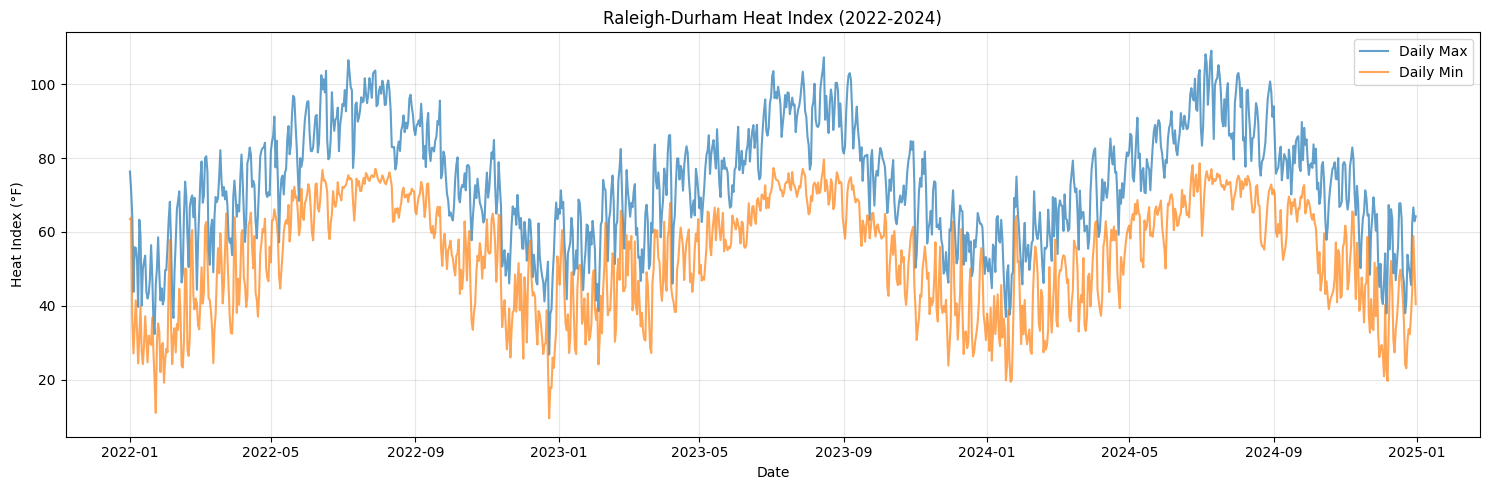


Summary statistics for Raleigh-Durham:
       heatindexmax2m  heatindexmin2m
count     1096.000000     1096.000000
mean        73.525650       53.648682
std         15.720617       14.963341
min         26.808136        9.527740
25%         62.878557       41.540032
50%         73.945198       55.940144
75%         84.933723       66.348593
max        109.058823       79.589531


In [35]:
import matplotlib.pyplot as plt

# Plot one station as example
station = 'KRDU'  # Change to any station code
df = daily_data[station]

plt.figure(figsize=(15, 5))
plt.plot(df['datetime'], df['heatindexmax2m'], label='Daily Max', alpha=0.7)
plt.plot(df['datetime'], df['heatindexmin2m'], label='Daily Min', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Heat Index (°F)')
plt.title(f'{STATIONS[station]["name"]} Heat Index (2022-2024)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary statistics for {STATIONS[station]['name']}:")
print(df[['heatindexmax2m', 'heatindexmin2m']].describe())

In [ ]:
# #!/usr/bin/env python3
# """
# Fix datetime formatting in ERA5 heat index files

# This script converts Excel serial numbers or improperly formatted dates
# back to proper datetime format.
# """

# import pandas as pd
# from pathlib import Path
# import sys
# import shutil

# def fix_datetime_in_file(filepath, backup=True):
#     """Fix datetime formatting in a single file"""
#     print(f"\n{'='*80}")
#     print(f"Processing: {filepath.name}")
#     print('='*80)
    
#     # Create backup if requested
#     if backup:
#         backup_path = filepath.with_suffix('.xlsx.backup')
#         shutil.copy2(filepath, backup_path)
#         print(f"✓ Backup created: {backup_path.name}")
    
#     # Read the file (explicitly specify engine)
#     df = pd.read_excel(filepath, engine='openpyxl')
#     print(f"  Loaded {len(df)} rows")
    
#     # Check if datetime column exists
#     if 'datetime' not in df.columns and 'date' not in df.columns:
#         print(f"  ❌ No datetime or date column found!")
#         return False
    
#     date_col = 'datetime' if 'datetime' in df.columns else 'date'
    
#     # Show original format
#     print(f"\n  Original {date_col} values (first 3):")
#     for i in range(min(3, len(df))):
#         print(f"    {df[date_col].iloc[i]}")
    
#     # Try to fix the datetime
#     original_dtype = df[date_col].dtype
    
#     try:
#         # Method 1: If it's Excel serial numbers
#         if pd.api.types.is_numeric_dtype(df[date_col]):
#             print(f"\n  Detected Excel serial numbers")
#             print(f"  Converting using Excel epoch (1900-01-01)...")
            
#             # Excel stores dates as days since 1900-01-01
#             # But Excel incorrectly treats 1900 as a leap year
#             # So we need to adjust
#             excel_epoch = pd.Timestamp('1899-12-30')
#             df[date_col] = df[date_col].apply(lambda x: excel_epoch + pd.Timedelta(days=x))
        
#         # Method 2: If it's already datetime but needs cleaning
#         elif pd.api.types.is_datetime64_any_dtype(df[date_col]):
#             print(f"\n  Already datetime format - normalizing...")
#             df[date_col] = pd.to_datetime(df[date_col])
        
#         # Method 3: If it's string, try to parse
#         else:
#             print(f"\n  Converting from {original_dtype} to datetime...")
#             df[date_col] = pd.to_datetime(df[date_col])
        
#         # Ensure it's just the date part (no time)
#         df[date_col] = df[date_col].dt.normalize()
        
#         # Show fixed format
#         print(f"\n  Fixed {date_col} values (first 3):")
#         for i in range(min(3, len(df))):
#             print(f"    {df[date_col].iloc[i].date()}")
        
#         print(f"  Last value: {df[date_col].iloc[-1].date()}")
        
#         # Verify date range is reasonable
#         min_date = df[date_col].min()
#         max_date = df[date_col].max()
        
#         if min_date.year < 2022 or max_date.year > 2025:
#             print(f"\n  ⚠️  WARNING: Date range looks suspicious!")
#             print(f"     Range: {min_date.date()} to {max_date.date()}")
#             print(f"     Expected: 2022-01-01 to ~2024-12-31")
#             response = input("     Continue anyway? (y/n): ")
#             if response.lower() != 'y':
#                 return False
        
#         # Save the fixed file (explicitly specify engine)
#         df.to_excel(filepath, index=False, engine='openpyxl')
#         print(f"\n  ✓ Fixed file saved: {filepath.name}")
#         return True
        
#     except Exception as e:
#         print(f"\n  ❌ Error fixing datetime: {e}")
#         import traceback
#         traceback.print_exc()
#         return False


# def main():
#     print("="*80)
#     print("DATETIME FORMAT FIXER FOR ERA5 FILES")
#     print("="*80)
#     print("\nThis script will:")
#     print("  1. Create backups of your files (.xlsx.backup)")
#     print("  2. Convert datetime columns to proper format")
#     print("  3. Verify the date range is correct")
    
#     # Find ERA5 files
#     current_dir = Path('.')
#     era5_files = list(current_dir.glob('*heatindex20222024*.xlsx'))
    
#     if not era5_files:
#         print("\n❌ No ERA5 files found in current directory")
#         print("\nUsage:")
#         print("  python fix_datetime_format.py")
#         print("\nMake sure you're in the directory with your ERA5 files")
#         sys.exit(1)
    
#     print(f"\nFound {len(era5_files)} ERA5 file(s):")
#     for f in era5_files:
#         print(f"  - {f.name}")
    
#     # Confirm
#     print("\n⚠️  WARNING: This will modify your files (backups will be created)")
#     response = input("Continue? (y/n): ")
    
#     if response.lower() != 'y':
#         print("Cancelled")
#         sys.exit(0)
    
#     # Process each file
#     results = {}
#     for filepath in era5_files:
#         success = fix_datetime_in_file(filepath, backup=True)
#         results[filepath.name] = success
    
#     # Summary
#     print(f"\n{'='*80}")
#     print("SUMMARY")
#     print('='*80)
    
#     success_count = sum(1 for v in results.values() if v)
    
#     print(f"\nSuccessfully fixed: {success_count}/{len(results)} files")
    
#     if success_count == len(results):
#         print("\n✓ All files fixed!")
#         print("  You can now proceed with the merge")
#         print("\n  Backups are saved as: [filename].xlsx.backup")
#         print("  You can delete them once you've verified the merge works")
#     else:
#         print("\n⚠️  Some files could not be fixed:")
#         for fname, success in results.items():
#             if not success:
#                 print(f"    - {fname}")
#         print("\n  Please check the error messages above")


# if __name__ == '__main__':
#     if len(sys.argv) > 1:
#         check_dir = Path(sys.argv[1])
#         if check_dir.exists():
#             import os
#             os.chdir(check_dir)
    
#     main()

DATETIME FORMAT FIXER FOR ERA5 FILES

This script will:
  1. Create backups of your files (.xlsx.backup)
  2. Convert datetime columns to proper format
  3. Verify the date range is correct

Found 7 ERA5 file(s):
  - KILMheatindex20222024_era5.xlsx
  - KCLTheatindex20222024_era5.xlsx
  - KGSOheatindex20222024_era5.xlsx
  - KRDUheatindex20222024_era5.xlsx
  - KAVLheatindex20222024_era5.xlsx
  - ~$KILMheatindex20222024_era5.xlsx
  - KHSEheatindex20222024_era5.xlsx

⚠️  WARNING: This will modify your files (backups will be created)

Processing: KILMheatindex20222024_era5.xlsx
✓ Backup created: KILMheatindex20222024_era5.xlsx.backup
  Loaded 1096 rows

  Original datetime values (first 3):
    2022-01-01 00:00:00
    2022-01-02 00:00:00
    2022-01-03 00:00:00

  Already datetime format - normalizing...

  Fixed datetime values (first 3):
    2022-01-01
    2022-01-02
    2022-01-03
  Last value: 2024-12-31

  ✓ Fixed file saved: KILMheatindex20222024_era5.xlsx

Processing: KCLTheatindex20

BadZipFile: File is not a zip file

## Summary

### Files Created:
- `KAVLheatindex20222024_era5.xlsx`
- `KRDUheatindex20222024_era5.xlsx`
- `KCLTheatindex20222024_era5.xlsx`
- `KGSOheatindex20222024_era5.xlsx`
- `KILMheatindex20222024_era5.xlsx`
- `KHSEheatindex20222024_era5.xlsx`

### Next Steps:
1. Review the Excel files to verify data quality
2. Run the merge notebook to combine with 1971-2021 data
3. Update your Streamlit dashboard with the merged files

In [43]:
#!/usr/bin/env python3
"""
Merge Heat Index Data: 1971-2021 + 2022-2024

This script merges existing ASOS station data (1971-2021) with new ERA5 data 
(2022-2024) to create complete 1971-2024 datasets.

Usage:
    python merge_heat_index_data.py
"""

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


# Configuration
STATIONS = {
    'KAVL': 'Asheville',
    'KRDU': 'Raleigh-Durham',
    'KCLT': 'Charlotte',
    'KGSO': 'Greensboro',
    'KILM': 'Wilmington',
    'KHSE': 'Cape Hatteras'
}

# Adjust these paths to your directory structure
HISTORICAL_DIR = Path('/Users/shawnkairu/VSCODE/PlanetLab/NC Heat/heat_index_files')  # Directory with 1971-2021 files
ERA5_DIR = Path('/Users/shawnkairu/VSCODE/PlanetLab/NC Heat')        # Directory with 2022-2024 ERA5 files
OUTPUT_DIR = Path('merged_output')
OUTPUT_DIR.mkdir(exist_ok=True)


def load_historical_data(station_code, directory):
    """Load 1971-2021 ASOS data"""
    # Handle KCLT filename discrepancy
    if station_code == 'KRDU':
        filename = 'KRDU-heat-index-1971-2021.xlsx'
    elif station_code == 'KCLT':
        filename = 'KLCT-heatindex-1971-2021.xlsx'
    else:
        filename = f'{station_code}-heatindex-1971-2021.xlsx'
    
    filepath = directory / filename
    
    df = pd.read_excel(filepath, engine='openpyxl')
    
    # Standardize column names
    if 'date' in df.columns:
        df.rename(columns={'date': 'datetime'}, inplace=True)
    
    # Convert datetime and numeric columns
    df['datetime'] = pd.to_datetime(df['datetime'])
    
    for col in ['heatindexmax2m', 'heatindexmin2m', 'heatindexavg2m']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Calculate average if missing
    if 'heatindexavg2m' not in df.columns or df['heatindexavg2m'].isna().all():
        df['heatindexavg2m'] = (df['heatindexmax2m'] + df['heatindexmin2m']) / 2
    
    return df


def load_era5_data(station_code, directory):
    """Load 2022-2024 ERA5 data"""
    filename = f'{station_code}heatindex20222024_era5.xlsx'
    filepath = directory / filename
    
    if not filepath.exists():
        return None
    
    df = pd.read_excel(filepath, engine='openpyxl')
    
    # Convert datetime and numeric columns
    df['datetime'] = pd.to_datetime(df['datetime'])
    
    for col in ['heatindexmax2m', 'heatindexmin2m']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Calculate average
    df['heatindexavg2m'] = (df['heatindexmax2m'] + df['heatindexmin2m']) / 2
    
    return df


def merge_datasets(hist_df, era5_df):
    """Merge historical and ERA5 datasets"""
    required_cols = ['datetime', 'heatindexmax2m', 'heatindexmin2m', 'heatindexavg2m']
    
    hist_df = hist_df[required_cols].copy()
    era5_df = era5_df[required_cols].copy()
    
    # Concatenate
    merged = pd.concat([hist_df, era5_df], ignore_index=True)
    
    # Remove duplicates (keep first = historical)
    merged = merged.drop_duplicates(subset=['datetime'], keep='first')
    
    # Sort by date
    merged = merged.sort_values('datetime').reset_index(drop=True)
    
    return merged


def main():
    """Main processing function"""
    print("="*80)
    print("HEAT INDEX DATA MERGE: 1971-2024")
    print("="*80)
    print(f"\nConfiguration:")
    print(f"  Historical data: {HISTORICAL_DIR.absolute()}")
    print(f"  ERA5 data: {ERA5_DIR.absolute()}")
    print(f"  Output: {OUTPUT_DIR.absolute()}")
    print(f"  Stations: {len(STATIONS)}")
    
    merged_datasets = {}
    summary_data = []
    
    # Process each station
    for station_code, station_name in STATIONS.items():
        print(f"\n{'-'*80}")
        print(f"Processing: {station_code} - {station_name}")
        print('-'*80)
        
        try:
            # Load data
            print(f"  Loading historical data...")
            hist = load_historical_data(station_code, HISTORICAL_DIR)
            print(f"    ✓ {len(hist)} records ({hist['datetime'].min().date()} to {hist['datetime'].max().date()})")
            
            print(f"  Loading ERA5 data...")
            era5 = load_era5_data(station_code, ERA5_DIR)
            
            if era5 is None:
                print(f"    ⚠️  ERA5 file not found - skipping")
                continue
            
            print(f"    ✓ {len(era5)} records ({era5['datetime'].min().date()} to {era5['datetime'].max().date()})")
            
            # Check continuity
            hist_end = hist['datetime'].max()
            era5_start = era5['datetime'].min()
            gap = (era5_start - hist_end).days
            
            print(f"  Gap between datasets: {gap} days")
            if gap == 1:
                print(f"    ✓ Perfect continuity")
            elif gap > 1:
                print(f"    ⚠️  {gap-1} missing days")
            elif gap <= 0:
                print(f"    ⚠️  {abs(gap)} overlapping days (will keep historical)")
            
            # Merge
            print(f"  Merging datasets...")
            merged = merge_datasets(hist, era5)
            print(f"    ✓ {len(merged)} total records")
            
            # Check for gaps
            date_range = pd.date_range(start=merged['datetime'].min(), 
                                      end=merged['datetime'].max(), 
                                      freq='D')
            missing = set(date_range) - set(merged['datetime'])
            
            if missing:
                print(f"    ⚠️  {len(missing)} missing dates in merged data")
            else:
                print(f"    ✓ Complete daily record (no gaps)")
            
            # Save
            if station_code == 'KCLT':
                output_file = OUTPUT_DIR / 'KLCTheatindex19712024.xlsx'
            else:
                output_file = OUTPUT_DIR / f'{station_code}heatindex19712024.xlsx'
            
            merged_save = merged.copy()
            merged_save.rename(columns={'datetime': 'date'}, inplace=True)
            merged_save.to_excel(output_file, index=False, engine='openpyxl')
            
            print(f"  ✓ Saved: {output_file.name}")
            
            # Store for summary
            merged_datasets[station_code] = merged
            summary_data.append({
                'Station': station_code,
                'Name': station_name,
                'Total Days': len(merged),
                'Start': merged['datetime'].min().strftime('%Y-%m-%d'),
                'End': merged['datetime'].max().strftime('%Y-%m-%d'),
                'Max Temp': f"{merged['heatindexmax2m'].max():.1f}",
                'Min Temp': f"{merged['heatindexmin2m'].min():.1f}"
            })
            
        except Exception as e:
            print(f"  ❌ Error: {e}")
            import traceback
            traceback.print_exc()
    
    # Print summary
    print(f"\n{'='*80}")
    print("SUMMARY")
    print('='*80)
    
    if summary_data:
        summary_df = pd.DataFrame(summary_data)
        print(summary_df.to_string(index=False))
        
        print(f"\n✓ Successfully merged {len(merged_datasets)} stations")
        print(f"✓ Output files saved to: {OUTPUT_DIR.absolute()}")
    else:
        print("❌ No stations were successfully merged")
    
    print("\nNext steps:")
    print("  1. Verify the merged files")
    print("  2. Copy them to your Streamlit project directory")
    print("  3. Update app.py to load the 1971-2024 files")


if __name__ == '__main__':
    main()

HEAT INDEX DATA MERGE: 1971-2024

Configuration:
  Historical data: /Users/shawnkairu/VSCODE/PlanetLab/NC Heat/heat_index_files
  ERA5 data: /Users/shawnkairu/VSCODE/PlanetLab/NC Heat
  Output: /Users/shawnkairu/VSCODE/PlanetLab/NC Heat/merged_output
  Stations: 6

--------------------------------------------------------------------------------
Processing: KAVL - Asheville
--------------------------------------------------------------------------------
  Loading historical data...
    ✓ 18628 records (1971-01-01 to 2021-12-31)
  Loading ERA5 data...
    ✓ 1096 records (2022-01-01 to 2024-12-31)
  Gap between datasets: 1 days
    ✓ Perfect continuity
  Merging datasets...
    ✓ 19724 total records
    ✓ Complete daily record (no gaps)
  ✓ Saved: KAVLheatindex19712024.xlsx

--------------------------------------------------------------------------------
Processing: KRDU - Raleigh-Durham
--------------------------------------------------------------------------------
  Loading historical 

In [44]:
#!/usr/bin/env python3
"""
Filter merged 1971-2024 heat index data to 1974-2024

This script reads the 1971-2024 files and creates new files starting from 1974.
"""

import pandas as pd
from pathlib import Path
import sys

# Configuration
STATIONS = {
    'KAVL': 'Asheville',
    'KRDU': 'Raleigh-Durham',
    'KCLT': 'Charlotte',
    'KGSO': 'Greensboro',
    'KILM': 'Wilmington',
    'KHSE': 'Cape Hatteras'
}

# File paths
INPUT_DIR = Path('/Users/shawnkairu/VSCODE/PlanetLab/NC Heat/merged_output')  # Directory with 1971-2024 files
OUTPUT_DIR = Path('filtered_1974_2024')
OUTPUT_DIR.mkdir(exist_ok=True)

# Date range
START_YEAR = 1974
END_YEAR = 2024


def filter_to_1974_2024(station_code, input_dir, output_dir):
    """Filter a single station's data to 1974-2024"""
    
    # Determine input filename
    if station_code == 'KCLT':
        input_file = input_dir / 'KLCTheatindex19712024.xlsx'
        output_file = output_dir / 'KLCTheatindex19742024.xlsx'
    else:
        input_file = input_dir / f'{station_code}heatindex19712024.xlsx'
        output_file = output_dir / f'{station_code}heatindex19742024.xlsx'
    
    print(f"\n{'='*80}")
    print(f"Processing: {station_code} - {STATIONS[station_code]}")
    print('='*80)
    
    # Check if input file exists
    if not input_file.exists():
        print(f"❌ Input file not found: {input_file}")
        return False
    
    # Read the file
    print(f"  Reading: {input_file.name}")
    df = pd.read_excel(input_file, engine='openpyxl')
    
    # Check column names
    date_col = 'date' if 'date' in df.columns else 'datetime'
    
    # Convert to datetime
    df[date_col] = pd.to_datetime(df[date_col])
    
    original_count = len(df)
    print(f"  Original records: {original_count}")
    print(f"  Date range: {df[date_col].min().date()} to {df[date_col].max().date()}")
    
    # Filter to 1974-2024
    df_filtered = df[(df[date_col].dt.year >= START_YEAR) & 
                     (df[date_col].dt.year <= END_YEAR)].copy()
    
    filtered_count = len(df_filtered)
    removed_count = original_count - filtered_count
    
    print(f"\n  Filtered records: {filtered_count}")
    print(f"  Removed records: {removed_count} (years 1971-1973)")
    print(f"  New date range: {df_filtered[date_col].min().date()} to {df_filtered[date_col].max().date()}")
    
    # Calculate expected days
    years_span = END_YEAR - START_YEAR + 1
    expected_days = years_span * 365.25
    
    print(f"\n  Expected days for {years_span} years: ~{expected_days:.0f}")
    print(f"  Actual days: {filtered_count}")
    
    if abs(filtered_count - expected_days) > 50:  # Allow for leap years and missing data
        print(f"  ⚠️  Warning: Day count differs from expected by {abs(filtered_count - expected_days):.0f} days")
    
    # Check for gaps
    date_range = pd.date_range(start=df_filtered[date_col].min(), 
                               end=df_filtered[date_col].max(), 
                               freq='D')
    missing = set(date_range) - set(df_filtered[date_col])
    
    if missing:
        print(f"  ⚠️  {len(missing)} missing dates in filtered data")
        if len(missing) <= 10:
            print(f"    Missing: {sorted([d.date() for d in missing])}")
    else:
        print(f"  ✓ Complete daily record (no gaps)")
    
    # Save filtered data
    df_filtered.to_excel(output_file, index=False, engine='openpyxl')
    print(f"\n  ✓ Saved: {output_file}")
    print(f"    Size: {output_file.stat().st_size / 1024:.1f} KB")
    
    return True


def main():
    """Main processing function"""
    print("="*80)
    print("FILTER HEAT INDEX DATA: 1974-2024")
    print("="*80)
    print(f"\nConfiguration:")
    print(f"  Input directory: {INPUT_DIR.absolute()}")
    print(f"  Output directory: {OUTPUT_DIR.absolute()}")
    print(f"  Date range: {START_YEAR}-01-01 to {END_YEAR}-12-31")
    print(f"  Stations: {len(STATIONS)}")
    
    # Check if input files exist
    print(f"\n{'='*80}")
    print("CHECKING INPUT FILES")
    print('='*80)
    
    missing_files = []
    for station_code in STATIONS.keys():
        if station_code == 'KCLT':
            filename = 'KLCTheatindex19712024.xlsx'
        else:
            filename = f'{station_code}heatindex19712024.xlsx'
        
        filepath = INPUT_DIR / filename
        if filepath.exists():
            size = filepath.stat().st_size / 1024
            print(f"  ✓ {filename} ({size:.1f} KB)")
        else:
            print(f"  ❌ {filename} (not found)")
            missing_files.append(filename)
    
    if missing_files:
        print(f"\n❌ Missing {len(missing_files)} input file(s):")
        for f in missing_files:
            print(f"    - {f}")
        print(f"\nPlease ensure the merged 1971-2024 files are in: {INPUT_DIR.absolute()}")
        sys.exit(1)
    
    # Process each station
    print(f"\n{'='*80}")
    print("PROCESSING STATIONS")
    print('='*80)
    
    results = {}
    summary_data = []
    
    for station_code, station_name in STATIONS.items():
        success = filter_to_1974_2024(station_code, INPUT_DIR, OUTPUT_DIR)
        results[station_code] = success
        
        if success:
            # Load filtered file for summary
            if station_code == 'KCLT':
                output_file = OUTPUT_DIR / 'KLCTheatindex19742024.xlsx'
            else:
                output_file = OUTPUT_DIR / f'{station_code}heatindex19742024.xlsx'
            
            df = pd.read_excel(output_file, engine='openpyxl')
            date_col = 'date' if 'date' in df.columns else 'datetime'
            df[date_col] = pd.to_datetime(df[date_col])
            
            summary_data.append({
                'Station': station_code,
                'Name': station_name,
                'Total Days': len(df),
                'Start Date': df[date_col].min().strftime('%Y-%m-%d'),
                'End Date': df[date_col].max().strftime('%Y-%m-%d'),
                'Years': f"{START_YEAR}-{END_YEAR}"
            })
    
    # Summary
    print(f"\n{'='*80}")
    print("SUMMARY")
    print('='*80)
    
    success_count = sum(1 for v in results.values() if v)
    
    if summary_data:
        summary_df = pd.DataFrame(summary_data)
        print(f"\n{summary_df.to_string(index=False)}")
    
    print(f"\n✓ Successfully filtered: {success_count}/{len(STATIONS)} stations")
    print(f"✓ Output files in: {OUTPUT_DIR.absolute()}")
    
    print(f"\n{'='*80}")
    print("NEXT STEPS")
    print('='*80)
    print(f"\n1. Verify the filtered files in: {OUTPUT_DIR.absolute()}")
    print(f"2. Copy them to your Streamlit project directory")
    print(f"3. Update app.py to load the 1974-2024 files")
    print(f"   - Change file names: '19712024' → '19742024'")
    print(f"   - Update references: '1971-2024' → '1974-2024'")
    print(f"   - Update year count: 54 years → 51 years")
    print(f"\nSee: UPDATE_APP_1974_2024.md for detailed instructions")


if __name__ == '__main__':
    main()

FILTER HEAT INDEX DATA: 1974-2024

Configuration:
  Input directory: /Users/shawnkairu/VSCODE/PlanetLab/NC Heat/merged_output
  Output directory: /Users/shawnkairu/VSCODE/PlanetLab/NC Heat/filtered_1974_2024
  Date range: 1974-01-01 to 2024-12-31
  Stations: 6

CHECKING INPUT FILES
  ✓ KAVLheatindex19712024.xlsx (494.8 KB)
  ✓ KRDUheatindex19712024.xlsx (586.4 KB)
  ✓ KLCTheatindex19712024.xlsx (499.6 KB)
  ✓ KGSOheatindex19712024.xlsx (598.4 KB)
  ✓ KILMheatindex19712024.xlsx (498.9 KB)
  ✓ KHSEheatindex19712024.xlsx (495.5 KB)

PROCESSING STATIONS

Processing: KAVL - Asheville
  Reading: KAVLheatindex19712024.xlsx
  Original records: 19724
  Date range: 1971-01-01 to 2024-12-31

  Filtered records: 18628
  Removed records: 1096 (years 1971-1973)
  New date range: 1974-01-01 to 2024-12-31

  Expected days for 51 years: ~18628
  Actual days: 18628
  ✓ Complete daily record (no gaps)

  ✓ Saved: filtered_1974_2024/KAVLheatindex19742024.xlsx
    Size: 468.7 KB

Processing: KRDU - Raleigh